# Figure 3

This notebook generates, processes, and visualises all subfigures for Figure 3 in one place. It writes Figure-3-specific intermediate pickle payloads into `raw_data/` and `processed_data/`, then saves the composed figure into `figures/pdf/`, `figures/png/`, and `figures/eps/`.


## Setup

Load the simulation, processing, and plotting tools used by the standalone Figure 3 workflow.


In [45]:
%load_ext autoreload
%autoreload 2

import pickle
from pathlib import Path

import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm

from slide.data_generation import nk_grid_pairs, run_nk_diffusion_replicates
from slide.data_processing import (
    nk_metric_comparison_from_accuracy,
    process_mutation_accuracy,
    process_popsize_accuracy,
    process_ruggedness_accuracy,
)
from slide.direvo_functions import get_single_decay_rate, model_function
from slide.utils import get_figures_dir, get_processed_data_dir, get_raw_data_dir, load_pickle, save_pickle

OVERWRITE_PKL: bool = False
SAVE_FIGURES: bool = True
SAVE_TYPE_LIST = ("pdf", "png", "eps")
PANEL_DPI = 350


RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
for figure_type in SAVE_TYPE_LIST:
    (FIGURES_DIR / figure_type).mkdir(parents=True, exist_ok=True)

print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")



def save_panel_figure(fig: plt.Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save an individual panel figure in every configured output format."""
    if not SAVE_FIGURES:
        return
    for figure_type in SAVE_TYPE_LIST:
        fig.savefig(FIGURES_DIR / figure_type / f"{stem}.{figure_type}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: plt.Axes, letter: str) -> None:
    """Add the panel letter annotation used in the paper figures."""
    ax.text(-0.16, 1.08, letter, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top", ha="left")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/lady5906/workspace_python/SLIDE/raw_data
processed_data: /home/lady5906/workspace_python/SLIDE/processed_data
figures: /home/lady5906/workspace_python/SLIDE/figures


## Figure 3 Files

Define all Figure-3-specific filenames. Run-defining parameter dictionaries are declared in the raw-generation cells that use them, so each saved payload is local to the computation that created it.


In [46]:
RAW_FILES = {
    "nk_decay_grid": "figure3_nk_decay_grid_raw.pkl",
    "nk_popsize_accuracy": "figure3_nk_popsize_accuracy_raw.pkl",
    "nk_mutation_accuracy": "figure3_nk_mutation_accuracy_raw.pkl",
}

PROCESSED_FILES = {
    "decay_examples": "figure3_decay_examples_processed.pkl",
    "ruggedness_accuracy": "figure3_ruggedness_accuracy_processed.pkl",
    "popsize_accuracy": "figure3_popsize_accuracy_processed.pkl",
    "mutation_accuracy": "figure3_mutation_accuracy_processed.pkl",
    "metric_comparison": "figure3_metric_comparison_processed.pkl",
}


## Raw Data Generation

Generate the raw NK diffusion products needed for all Figure 3 panels and save them as payload dictionaries with `data`, `params`, and `metadata`. Each section first defines the run parameters and output path, then the generation cell checks whether the target raw pickle already exists before starting the expensive loop. Set `OVERWRITE_PKL = True` to regenerate an existing raw file.


### NK Decay Grid - Panels A, B, And E

Generate the large NK no-selection diffusion grid used for example decay curves, ruggedness prediction accuracy, and metric comparison. Each diffusion starts from a random genotype and records mean population fitness trajectories $F_\mu$ over generations $M$.


In [103]:
OVERWRITE_PKL = True
grid_params = {
    "N_range": (20, 20),  # TODO "N_range": (10, 50),
    "num_grid_samples": 10,
    "A": 2,
    "mutation_rate": 0.5,
    "popsize": 5000,  # TODO "popsize": 2500,
    "num_landscapes": 25,
    "num_reps_per_landscape": 100,
    "M": 25,
    "seed": 20, # TODO "seed": 42,
    "random_starting_genotype": True,
}
nk_pairs = nk_grid_pairs(
    grid_params["N_range"],
    grid_params["num_grid_samples"],
    K_start=0,
)
grid_params["nk_pairs"] = list(dict.fromkeys(nk_pairs))  # Remove duplicates

nk_decay_grid_path = RAW_DATA_DIR / RAW_FILES["nk_decay_grid"]

print("\n---\nNK grid parameters:")
for key, value in grid_params.items():
    print(f"  {key}: {value}")
print(f"Save path: {nk_decay_grid_path}")
print("---\n")

# try:
if nk_decay_grid_path.exists() and not OVERWRITE_PKL:
    raise FileExistsError(f"{nk_decay_grid_path} already exists. Set OVERWRITE_PKL = True to overwrite it.")

rep_keys = jr.split(jr.PRNGKey(grid_params["seed"]), grid_params["num_landscapes"])
nk_decay_grid = []

for N, K in tqdm(grid_params["nk_pairs"], desc="Figure 3 NK decay grid"):
    pair_results = []
    for key in rep_keys:
        start = (
            np.asarray(jr.randint(rep_keys[0], (N,), 0, grid_params["A"]), dtype=np.int32)
            if grid_params["random_starting_genotype"]
            else np.zeros(N, dtype=np.int32)
        )
        run = run_nk_diffusion_replicates(
            key,
            n_sites=N,
            k=K,
            num_alleles=grid_params["A"],
            start=start,
            popsize=grid_params["popsize"],
            mutation_rate=grid_params["mutation_rate"] / N,
            num_reps=grid_params["num_reps_per_landscape"],
            num_steps=grid_params["M"],
        )
        pair_results.append(run["fitness"].mean(axis=-1))
    nk_decay_grid.append(np.asarray(pair_results))

nk_decay_grid_payload = {
    "data": np.asarray(nk_decay_grid),
    "params": grid_params,
    "metadata": {
        "description": "Raw NK no-selection diffusion grid for Figure 3 panels A, B, and E.",
        "paper_reference": "Figure 3A-B/E",
        "output_key": "figure3_nk_decay_grid",
        "filename": RAW_FILES["nk_decay_grid"],
    },
}
save_pickle(nk_decay_grid_payload, nk_decay_grid_path)
# except FileExistsError as e:
#     print(e)
#     nk_decay_grid_payload = load_pickle(nk_decay_grid_path)



---
NK grid parameters:
  N_range: (20, 20)
  num_grid_samples: 10
  A: 2
  mutation_rate: 0.5
  popsize: 5000
  num_landscapes: 25
  num_reps_per_landscape: 100
  M: 25
  seed: 20
  random_starting_genotype: True
  nk_pairs: [(20, 19), (20, 16), (20, 14), (20, 12), (20, 10), (20, 8), (20, 6), (20, 4), (20, 2), (20, 0)]
Save path: /home/lady5906/workspace_python/SLIDE/raw_data/figure3_nk_decay_grid_raw.pkl
---



Figure 3 NK decay grid:   0%|          | 0/10 [00:00<?, ?it/s]

PosixPath('/home/lady5906/workspace_python/SLIDE/raw_data/figure3_nk_decay_grid_raw.pkl')

### Population-Size Accuracy Sweep - Panel C

Generate the population-size sensitivity sweep for fitted ruggedness $\rho_{fit}$. Each run uses random starting genotypes, matching the current edited Figure 3 generation parameters.


In [ ]:
popsize_params = {
    "N": 25,
    "K": 15,
    "A": 2,
    "num_lscapes": 25,
    "num_reps_per_lscape": 20,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "random_starting_genotype": True,
    "pop_sizes": np.logspace(start=1, stop=5, num=10, endpoint=True, dtype=int),
    "mutation_rate": 0.5,
    "fit_mutation_scale": 1.0,
}
popsize_params["rho_NK"] = (popsize_params["K"] + 1) / popsize_params["N"]

popsize_accuracy_path = RAW_DATA_DIR / RAW_FILES["nk_popsize_accuracy"]

print("\n---\nNK popsize parameters:")
for key, value in popsize_params.items():
    print(f"  {key}: {value}")
print(f"Save path: {popsize_accuracy_path}")
print("---\n")

try:
    if popsize_accuracy_path.exists() and not OVERWRITE_PKL:
        raise FileExistsError(f"{popsize_accuracy_path} already exists. Set OVERWRITE_PKL = True to overwrite it.")

    rep_keys = jr.split(jr.PRNGKey(popsize_params["seed"]), popsize_params["num_lscapes"])
    popsize_accuracy = []

    for popsize in tqdm(popsize_params["pop_sizes"], desc="Figure 3 popsize accuracy"):
        pop_results = []
        for key in rep_keys:
            start = (
                np.asarray(jr.randint(key, (popsize_params["N"],), 0, popsize_params["A"]), dtype=np.int32)
                if popsize_params["random_starting_genotype"]
                else np.zeros(popsize_params["N"], dtype=np.int32)
            )
            run = run_nk_diffusion_replicates(
                key,
                n_sites=popsize_params["N"],
                k=popsize_params["K"],
                num_alleles=popsize_params["A"],
                start=start,
                popsize=int(popsize),
                mutation_rate=popsize_params["mutation_rate"] / popsize_params["N"],
                num_reps=popsize_params["num_reps_per_lscape"],
                num_steps=popsize_params["M"],
            )
            pop_results.append(run["fitness"].mean(axis=-1))
        popsize_accuracy.append(np.asarray(pop_results))

    popsize_accuracy_payload = {
        "data": np.asarray(popsize_accuracy),
        "params": popsize_params,
        "metadata": {
            "description": "Raw NK population-size sensitivity sweep for Figure 3C.",
            "paper_reference": "Figure 3C",
            "output_key": "figure3_nk_popsize_accuracy",
            "filename": RAW_FILES["nk_popsize_accuracy"],
        },
    }
    save_pickle(popsize_accuracy_payload, popsize_accuracy_path)
except FileExistsError as e:
    print(e)
    popsize_accuracy_payload = load_pickle(popsize_accuracy_path)



---
NK popsize parameters:
  N: 25
  K: 15
  A: 2
  num_lscapes: 25
  num_reps_per_lscape: 20
  M: 25
  seed: 42
  start_policy: random
  random_starting_genotype: True
  pop_sizes: [    10     27     77    215    599   1668   4641  12915  35938 100000]
  mutation_rate: 0.5
  fit_mutation_scale: 1.0
  rho_NK: 0.64
Save path: /home/lady5906/workspace_python/SLIDE/raw_data/figure3_nk_popsize_accuracy_raw.pkl
---

/home/lady5906/workspace_python/SLIDE/raw_data/figure3_nk_popsize_accuracy_raw.pkl already exists. Set OVERWRITE_PKL = True to overwrite it.


### Mutation-Rate Accuracy Sweep - Panel D

Generate the mutation-rate sensitivity sweep for fitted ruggedness $\rho_{fit}$. The x-axis values are total mutations per cell per generation, $\theta$.


In [49]:
mutation_params = {
    "N": 25,
    "K": 15,
    "A": 2,
    "num_lscapes": 25,
    "num_reps_per_lscape": 20,
    "M": 25,
    "seed": 42,
    "start_policy": "random",
    "random_starting_genotype": True,
    "popsize": 2000,
    "mutation_rates": np.linspace(0.01, 2, 25),
}
mutation_params["rho_NK"] = (mutation_params["K"] + 1) / mutation_params["N"]

mutation_accuracy_path = RAW_DATA_DIR / RAW_FILES["nk_mutation_accuracy"]

print("\n---\nNK mutation parameters:")
for key, value in mutation_params.items():
    print(f"  {key}: {value}")
print(f"Save path: {mutation_accuracy_path}")
print("---\n")

try:
    if mutation_accuracy_path.exists() and not OVERWRITE_PKL:
        raise FileExistsError(f"{mutation_accuracy_path} already exists. Set OVERWRITE_PKL = True to overwrite it.")

    rep_keys = jr.split(jr.PRNGKey(mutation_params["seed"]), mutation_params["num_lscapes"])
    mutation_accuracy = []

    for mutation_rate in tqdm(mutation_params["mutation_rates"], desc="Figure 3 mutation-rate accuracy"):
        mu_results = []
        for key in rep_keys:
            start = (
                np.asarray(jr.randint(key, (mutation_params["N"],), 0, mutation_params["A"]), dtype=np.int32)
                if mutation_params["random_starting_genotype"]
                else np.zeros(mutation_params["N"], dtype=np.int32)
            )
            run = run_nk_diffusion_replicates(
                key,
                n_sites=mutation_params["N"],
                k=mutation_params["K"],
                num_alleles=mutation_params["A"],
                start=start,
                popsize=mutation_params["popsize"],
                mutation_rate=float(mutation_rate) / mutation_params["N"],
                num_reps=mutation_params["num_reps_per_lscape"],
                num_steps=mutation_params["M"],
            )
            mu_results.append(run["fitness"].mean(axis=-1))
        mutation_accuracy.append(np.asarray(mu_results))

    mutation_accuracy_payload = {
        "data": np.asarray(mutation_accuracy),
        "params": mutation_params,
        "metadata": {
            "description": "Raw NK mutation-rate sensitivity sweep for Figure 3D.",
            "paper_reference": "Figure 3D",
            "output_key": "figure3_nk_mutation_accuracy",
            "filename": RAW_FILES["nk_mutation_accuracy"],
        },
    }
    save_pickle(mutation_accuracy_payload, mutation_accuracy_path)
except FileExistsError as e:
    print(e)
    mutation_accuracy_payload = load_pickle(mutation_accuracy_path)


---
NK mutation parameters:
  N: 25
  K: 15
  A: 2
  num_lscapes: 25
  num_reps_per_lscape: 20
  M: 25
  seed: 42
  start_policy: random
  random_starting_genotype: True
  popsize: 2000
  mutation_rates: [0.01       0.09291667 0.17583333 0.25875    0.34166667 0.42458333
 0.5075     0.59041667 0.67333333 0.75625    0.83916667 0.92208333
 1.005      1.08791667 1.17083333 1.25375    1.33666667 1.41958333
 1.5025     1.58541667 1.66833333 1.75125    1.83416667 1.91708333
 2.        ]
  rho_NK: 0.64
Save path: /home/lady5906/workspace_python/SLIDE/raw_data/figure3_nk_mutation_accuracy_raw.pkl
---

/home/lady5906/workspace_python/SLIDE/raw_data/figure3_nk_mutation_accuracy_raw.pkl already exists. Set OVERWRITE_PKL = True to overwrite it.


## Processing

Load the Figure-3-specific raw payloads, compute the processed quantities needed by each panel, and save processed payloads with parameters and metadata.


In [104]:
nk_decay_grid_payload = load_pickle(RAW_DATA_DIR / RAW_FILES["nk_decay_grid"])
popsize_accuracy_payload = load_pickle(RAW_DATA_DIR / RAW_FILES["nk_popsize_accuracy"])
mutation_accuracy_payload = load_pickle(RAW_DATA_DIR / RAW_FILES["nk_mutation_accuracy"])

nk_decay_grid = nk_decay_grid_payload["data"]
nk_decay_params = nk_decay_grid_payload["params"]
nk_pairs = np.asarray(nk_decay_params["nk_pairs"])

popsize_accuracy_raw = popsize_accuracy_payload["data"]
popsize_params = popsize_accuracy_payload["params"]
mutation_accuracy_raw = mutation_accuracy_payload["data"]
mutation_params = mutation_accuracy_payload["params"]


### Panel A Processing

Select two explicit NK landscapes from the generated grid, average their normalized diffusion trajectories, and store both the curves and the selected `(N, K)` metadata for Figure 3A.


25
25
Figure 3A selected NK examples:
  smooth: grid_index=7, N=20, K=4, rho_NK=0.250, trajectories=10
  rugged: grid_index=3, N=20, K=12, rho_NK=0.650, trajectories=10


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


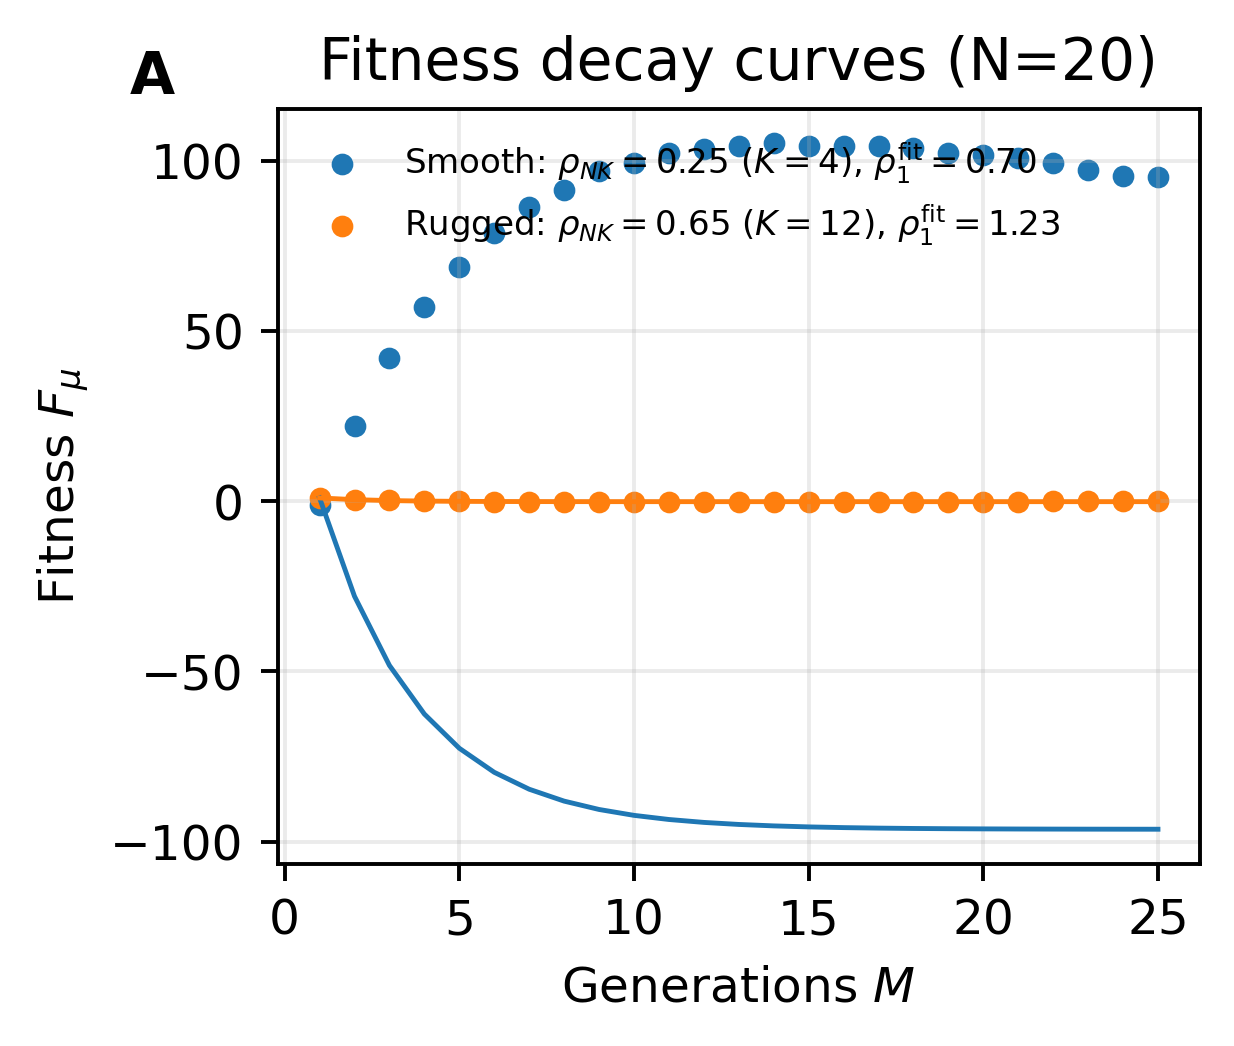

In [ ]:
# Select example pairs
N_select = nk_decay_params["N_range"][1]
N_K_pairs = [x for x in nk_decay_params["nk_pairs"] if x[0] == N_select]
PANEL_A_NK_EXAMPLES: dict[str, tuple[int, int]] = {
    "smooth": N_K_pairs[-2],
    "rugged": N_K_pairs[2],
}
assert PANEL_A_NK_EXAMPLES["smooth"][0] == PANEL_A_NK_EXAMPLES["rugged"][0], "Panel A examples must have the same N value for a fair comparison."
PANEL_A_TRAJECTORIES_PER_EXAMPLE = 10


def smooth_rugged_example(
    decay_grid: np.ndarray,
    nk_pairs: np.ndarray,
    selected_pairs: dict[str, tuple[int, int]],
    mut: float = 0.5,
    *,
    trajectories_per_example: int = 10,
    steps: int | None = None,
    use_Gmu: bool = False
) -> tuple[list[np.ndarray], list[np.ndarray], list[str], dict[str, dict[str, int | float | str]]]:
    """Extract explicitly selected NK example curves for Figure 3A.

    Parameters
    ----------
    decay_grid:
        Raw NK diffusion grid with the NK pair as the first axis and generation
        as the final axis. The intervening axes are collapsed into independent
        trajectories before averaging.
    nk_pairs:
        Array-like list of `(N, K)` pairs in the same order as `decay_grid`.
    selected_pairs:
        Named `(N, K)` examples to extract. The dictionary order controls the
        plotting order and is preserved in the returned labels.
    mut:
        Mutation rate of the diffusion experiment.
    trajectories_per_example:
        Number of normalized trajectories to average for each selected pair.
    steps:
        Number of generations in each trajectory. If omitted, the final axis of
        `decay_grid` is used.

    Returns
    -------
    curves, fitted_lines, labels, example_metadata:
        `curves` contains one normalized mean fitness trajectory per selected
        NK pair. `fitted_lines` contains the corresponding exponential model fits from
        `get_single_decay_rate` and `model_function`. `labels` are legend-ready strings containing the selected
        `(N, K)` values and analytical `rho_NK = (K + 1) / N` values.
        `example_metadata` records the grid index and numerical parameters for
        reproducibility.
    """
    decay_array = np.asarray(decay_grid, dtype=float)
    if steps is None:
        steps = int(decay_array.shape[-1])

    normalized = decay_array.reshape(decay_array.shape[0], -1, steps)
    normalized = normalized / np.abs(normalized[:, :, 0][:, :, None]+1e-12)
    pair_to_index = {
        (int(pair[0]), int(pair[1])): index
        for index, pair in enumerate(np.asarray(nk_pairs, dtype=int))
    }

    curves: list[np.ndarray] = []
    fitted_lines: list[np.ndarray] = []
    labels: list[str] = []
    example_metadata: dict[str, dict[str, int | float | str]] = {}

    for name, pair in selected_pairs.items():
        N, K = int(pair[0]), int(pair[1])
        pair_key = (N, K)
        if pair_key not in pair_to_index:
            available = ", ".join(f"N={n}, K={k}" for n, k in pair_to_index)
            raise ValueError(f"Selected Panel A pair N={N}, K={K} is not in the NK grid. Available pairs: {available}")

        grid_index = pair_to_index[pair_key]
        rho_nk = (K + 1) / N
        curve = normalized[grid_index, :trajectories_per_example].mean(axis=0)

        generations = np.arange(len(curve))
        print(len(generations))
        decay_params = get_single_decay_rate(decay_data=curve, mut=mut, num_steps=len(generations))
        rho_1 =  decay_params[0]  # Extract the fitted rho_1 from the decay parameters
        fitted_curve = model_function(generations, *decay_params, mut=mut)
        
        label = rf"{name.title()}: $\rho_{{NK}}={rho_nk:.2f}$ ($K={K}$), $\rho_{{1}}^{{\mathrm{{fit}}}}={rho_1:.2f}$"

        curves.append(curve)
        fitted_lines.append(fitted_curve)
        labels.append(label)
        example_metadata[name] = {
            "N": N,
            "K": K,
            "rho_NK": float(rho_nk),
            "grid_index": int(grid_index),
            "trajectories_per_example": int(trajectories_per_example),
            "legend_label": label,
        }

    return curves, fitted_lines, labels, example_metadata


smooth_rugged, fitted_lines, panel_a_labels, panel_a_examples = smooth_rugged_example(
    nk_decay_grid,
    nk_pairs,
    PANEL_A_NK_EXAMPLES,
    mut=nk_decay_params["mutation_rate"],
    trajectories_per_example=PANEL_A_TRAJECTORIES_PER_EXAMPLE,
    steps=int(nk_decay_params["M"]),
)

print("Figure 3A selected NK examples:")
for name, info in panel_a_examples.items():
    print(
        f"  {name}: grid_index={info['grid_index']}, "
        f"N={info['N']}, K={info['K']}, rho_NK={info['rho_NK']:.3f}, "
        f"trajectories={info['trajectories_per_example']}"
    )

decay_examples_payload = {
    "data": {
        "smooth_rugged": smooth_rugged,
        "fitted_lines": fitted_lines,
        "generations": np.arange(1, len(smooth_rugged[0]) + 1),
        "labels": panel_a_labels,
        "examples": panel_a_examples,
    },
    "params": {**nk_decay_params, "panel_a_examples": panel_a_examples},
    "metadata": {
        "description": "Processed explicitly selected NK decay examples for Figure 3A.",
        "paper_reference": "Figure 3A",
        "output_key": "figure3_decay_examples",
        "filename": PROCESSED_FILES["decay_examples"],
    },
}
save_pickle(decay_examples_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["decay_examples"])


# Plot figure
panel_data = decay_examples_payload["data"]
panel_generations = panel_data["generations"]
panel_curves = panel_data["smooth_rugged"]
panel_fitted_lines = panel_data["fitted_lines"]
panel_labels = panel_data["labels"]
panel_colours = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
for curve, fitted_line, label, colour in zip(panel_curves, panel_fitted_lines, panel_labels, panel_colours):
    ax.scatter(panel_generations, curve, label=label, color=colour, s=12)
    ax.plot(panel_generations, fitted_line, color=colour, linewidth=1)
ax.set_title(f"Fitness decay curves (N={PANEL_A_NK_EXAMPLES['smooth'][0]})")
ax.set_xlabel(r"Generations $M$")
ax.set_ylabel(r"Fitness $F_\mu$")
ax.legend(frameon=False, fontsize=7)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "A")
save_panel_figure(fig, "figure_3A")
plt.show()


### Panel B Processing

Fit decay rates and compare mean $\rho_{fit}$ against analytical $\rho_{NK}$.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


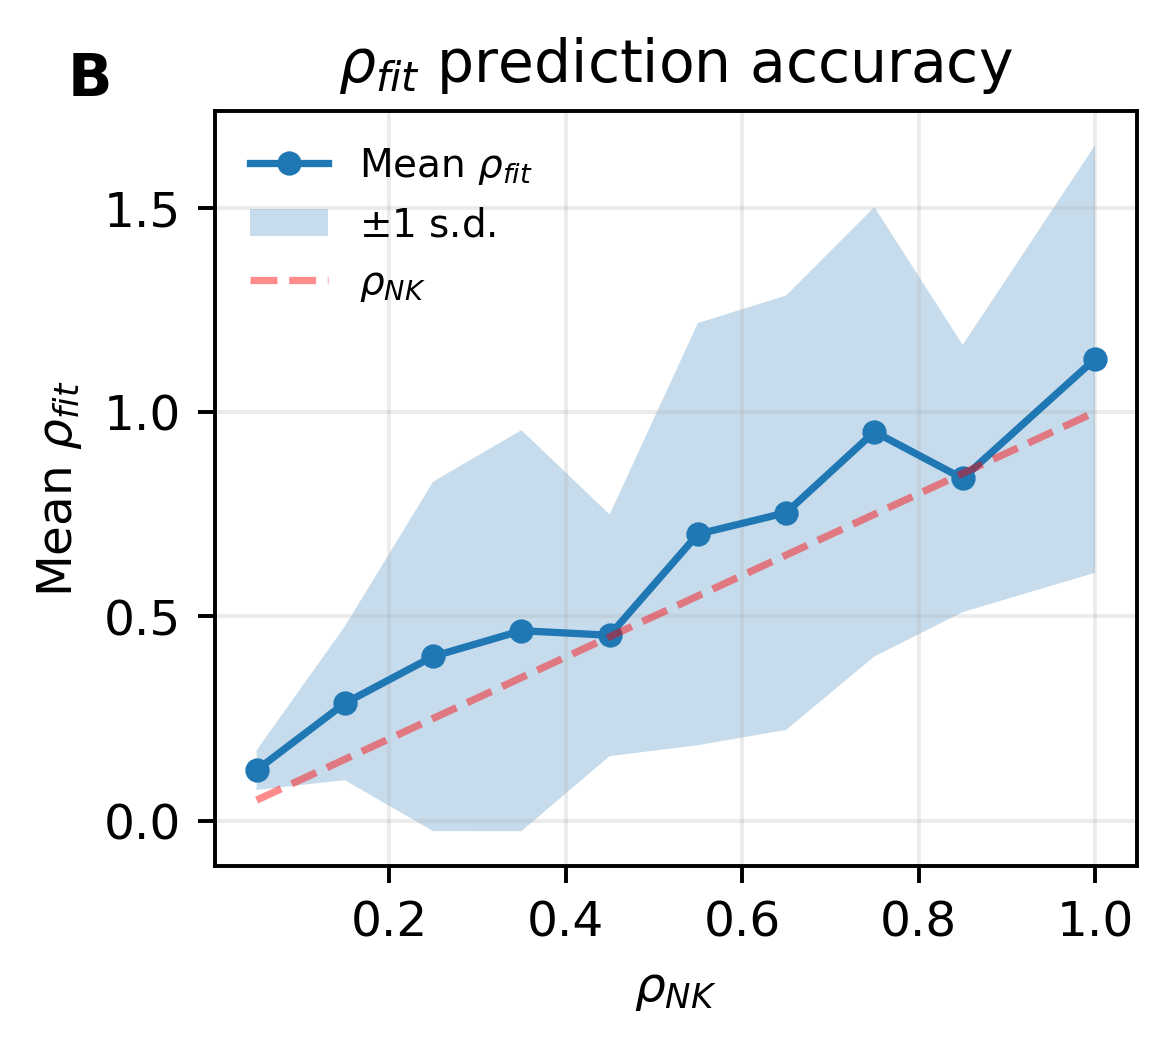

In [73]:
steps = int(nk_decay_params["M"])
fit_mutation_rate = float(nk_decay_params["mutation_rate"])

decay_array = np.asarray(nk_decay_grid)
normalized_curves = decay_array.reshape(decay_array.shape[0], -1, steps)
normalized_curves = normalized_curves / normalized_curves[:, :, 0][:, :, None]

rho_fit = np.zeros(normalized_curves.shape[:2], dtype=float)
for i in range(normalized_curves.shape[0]):
    for j in range(normalized_curves.shape[1]):
        rho_fit[i, j] = get_single_decay_rate(
            decay_data=normalized_curves[i, j],
            mut=fit_mutation_rate,
            num_steps=steps,
        )[0]

nk_pairs_array = np.asarray(nk_pairs)
rho_NK = (nk_pairs_array[:, 1] + 1) / nk_pairs_array[:, 0]
if any([x > 1 for x in rho_NK]):
    raise ValueError("Calculated rho_NK values must be in the range [0, 1]. Check the NK pairs and calculation.")

order = np.argsort(rho_NK)
sorted_rho_NK = rho_NK[order]
sorted_rho_fit = rho_fit[order]
num_grid_samples = int(nk_decay_params["num_grid_samples"])
grouped_rho_NK = sorted_rho_NK.reshape(num_grid_samples, -1)
grouped_rho_fit = sorted_rho_fit.reshape(num_grid_samples, -1)

ruggedness_accuracy_processed = {
    "rho_NK": grouped_rho_NK.mean(axis=1),
    "rho_fit_mean": grouped_rho_fit.mean(axis=1),
    "rho_fit_std": grouped_rho_fit.std(axis=1),
    "rho_fit_all": rho_fit,
    "rho_NK_all": rho_NK,
}
ruggedness_accuracy_payload = {
    "data": ruggedness_accuracy_processed,
    "params": nk_decay_params,
    "metadata": {
        "description": "Processed NK ruggedness prediction accuracy for Figure 3B.",
        "paper_reference": "Figure 3B",
        "output_key": "figure3_ruggedness_accuracy",
        "filename": PROCESSED_FILES["ruggedness_accuracy"],
    },
}
save_pickle(ruggedness_accuracy_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["ruggedness_accuracy"])


panel_data = ruggedness_accuracy_processed
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(panel_data["rho_NK"], panel_data["rho_fit_mean"], "o-", markersize=4, label=r"Mean $\rho_{fit}$")
ax.fill_between(
    panel_data["rho_NK"],
    panel_data["rho_fit_mean"] - panel_data["rho_fit_std"],
    panel_data["rho_fit_mean"] + panel_data["rho_fit_std"],
    alpha=0.25,
    label=r"$\pm$1 s.d.",
)
ax.plot(panel_data["rho_NK"], panel_data["rho_NK"], color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(r"$\rho_{fit}$ prediction accuracy")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel(r"Mean $\rho_{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")
save_panel_figure(fig, "figure_3B")
plt.show()


### Panel B Individual Export
This cell saves the annotated Figure 3B subfigure after the NK ruggedness calibration has been processed.


In [ ]:
panel_data = ruggedness_accuracy_processed
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(panel_data["rho_NK"], panel_data["rho_fit_mean"], "o-", markersize=4, label=r"Mean $\rho_{fit}$")
ax.fill_between(
    panel_data["rho_NK"],
    panel_data["rho_fit_mean"] - panel_data["rho_fit_std"],
    panel_data["rho_fit_mean"] + panel_data["rho_fit_std"],
    alpha=0.25,
    label=r"$\pm$1 s.d.",
)
ax.plot(panel_data["rho_NK"], panel_data["rho_NK"], color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(r"$\rho_{fit}$ prediction accuracy")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel(r"Mean $\rho_{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "B")
save_panel_figure(fig, "figure_3B")
plt.show()


### Panel C-D Processing

Fit $\rho_{fit}$ for the population-size and mutation-rate robustness sweeps.


In [ ]:
popsize_processed = process_popsize_accuracy(popsize_accuracy_raw, popsize_params)
popsize_processed["rho_NK"] = np.asarray(popsize_params["rho_NK"])
popsize_accuracy_processed_payload = {
    "data": popsize_processed,
    "params": popsize_params,
    "metadata": {
        "description": "Processed NK population-size robustness data for Figure 3C.",
        "paper_reference": "Figure 3C",
        "output_key": "figure3_popsize_accuracy",
        "filename": PROCESSED_FILES["popsize_accuracy"],
    },
}
save_pickle(popsize_accuracy_processed_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["popsize_accuracy"])

mutation_processed = process_mutation_accuracy(mutation_accuracy_raw, mutation_params)
mutation_processed["rho_NK"] = np.asarray(mutation_params["rho_NK"])
mutation_accuracy_processed_payload = {
    "data": mutation_processed,
    "params": mutation_params,
    "metadata": {
        "description": "Processed NK mutation-rate robustness data for Figure 3D.",
        "paper_reference": "Figure 3D",
        "output_key": "figure3_mutation_accuracy",
        "filename": PROCESSED_FILES["mutation_accuracy"],
    },
}
save_pickle(mutation_accuracy_processed_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["mutation_accuracy"])


### Panels C And D Individual Exports
This cell saves the annotated Figure 3C and Figure 3D subfigures after the robustness checks have been processed.


In [ ]:
pop_rates = popsize_processed["rates"]
pop_means = pop_rates.mean(axis=1)
pop_stds = pop_rates.std(axis=1)
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(popsize_processed["pop_sizes"], pop_means, "o-", markersize=4, label=r"Mean $\rho_{fit}$")
ax.fill_between(popsize_processed["pop_sizes"], pop_means - pop_stds, pop_means + pop_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(popsize_processed["rho_NK"]), color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_xscale("log")
ax.set_title("Accuracy over population size")
ax.set_xlabel("Population size")
ax.set_ylabel(r"Mean $\rho_{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "C")
save_panel_figure(fig, "figure_3C")
plt.show()

mut_rates = mutation_processed["rates"]
mut_means = mut_rates.mean(axis=1)
mut_stds = mut_rates.std(axis=1)
fig, ax = plt.subplots(figsize=(3.4, 2.8), dpi=PANEL_DPI)
ax.plot(mutation_processed["mutation_rates"], mut_means, "o-", markersize=4, label=r"Mean $\rho_{fit}$")
ax.fill_between(mutation_processed["mutation_rates"], mut_means - mut_stds, mut_means + mut_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(mutation_processed["rho_NK"]), color="red", alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title("Accuracy over mutation rate")
ax.set_xlabel(r"Mutations per cell per generation $\theta$")
ax.set_ylabel(r"Mean $\rho_{fit}$")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "D")
save_panel_figure(fig, "figure_3D")
plt.show()


### Panel E Processing

Build the NK ruggedness metric comparison curves used in Figure 3E.


In [ ]:
metric_comparison = nk_metric_comparison_from_accuracy(rho_NK, rho_fit)
metric_names = [
    "roughness_to_slope",
    "fourier",
    "rho_fit",
    "paths_to_max",
    "closest_max",
    "rho_NK",
    "local_epistasis",
]
metric_comparison_processed = dict(zip(metric_names, metric_comparison))
metric_comparison_payload = {
    "data": metric_comparison_processed,
    "params": nk_decay_params,
    "metadata": {
        "description": "Processed NK ruggedness metric comparison for Figure 3E.",
        "paper_reference": "Figure 3E",
        "output_key": "figure3_metric_comparison",
        "filename": PROCESSED_FILES["metric_comparison"],
    },
}
save_pickle(metric_comparison_payload, PROCESSED_DATA_DIR / PROCESSED_FILES["metric_comparison"])


### Panel E Individual Export
This cell saves the annotated Figure 3E subfigure after the metric comparison has been processed.


In [ ]:
panel_data = metric_comparison_processed
fig, ax = plt.subplots(figsize=(6.8, 2.9), dpi=PANEL_DPI)
rho_axis = panel_data["rho_NK"]
rho_curve = panel_data["rho_fit"]
ax.plot(rho_axis, rho_curve / rho_curve.max(), label=r"$\rho_{fit}$", linewidth=1.5)
ax.plot(rho_axis, 1 - panel_data["fourier"] / panel_data["fourier"].max(), label=r"1 - Landscape $R^2$", alpha=0.75, linestyle="--")
ax.plot(rho_axis, panel_data["roughness_to_slope"] / panel_data["roughness_to_slope"].max(), label="Roughness-to-slope ratio", alpha=0.75, linestyle="--")
ax.plot(rho_axis, 1 - panel_data["paths_to_max"] / panel_data["paths_to_max"].max(), label="1 - Paths to maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, panel_data["closest_max"] / panel_data["closest_max"].max(), label="Distance to closest local maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, panel_data["local_epistasis"] / panel_data["local_epistasis"].max(), label="Local epistasis", alpha=0.75, linestyle="--")
ax.set_title("Ruggedness metric comparison")
ax.set_xlabel(r"$\rho_{NK}$")
ax.set_ylabel("Normalised ruggedness measurements")
ax.legend(loc="lower right", fontsize=7, frameon=False, ncol=2)
ax.grid(True, alpha=0.25)
add_panel_letter(ax, "E")
save_panel_figure(fig, "figure_3E")
plt.show()


## Visualisation

Load the processed Figure 3 payloads and compose panels A-E into a single GridSpec figure with correct paper nomenclature.


In [ ]:
decay_examples_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["decay_examples"])
ruggedness_accuracy_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["ruggedness_accuracy"])
popsize_accuracy_processed_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["popsize_accuracy"])
mutation_accuracy_processed_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["mutation_accuracy"])
metric_comparison_payload = load_pickle(PROCESSED_DATA_DIR / PROCESSED_FILES["metric_comparison"])

decay_examples = decay_examples_payload["data"]
ruggedness_accuracy = ruggedness_accuracy_payload["data"]
popsize_accuracy_processed = popsize_accuracy_processed_payload["data"]
mutation_accuracy_processed = mutation_accuracy_processed_payload["data"]
metric_comparison = metric_comparison_payload["data"]


In [ ]:
# Figure styling.
c_decay_smooth = "tab:blue"
c_decay_rugged = "tab:orange"
c_reference = "red"
labelsize = 8
ticksize = 6
titlesize = 10
legendsize = 7
dpi = 350
plt.rcParams["font.family"] = "DejaVu Sans"

fig = plt.figure(figsize=(7.2, 6.4), dpi=dpi, constrained_layout=True)
gs = GridSpec(3, 2, figure=fig, height_ratios=[1.05, 0.82, 1.0])
axes = {
    "A": fig.add_subplot(gs[0, 0]),
    "B": fig.add_subplot(gs[0, 1]),
    "C": fig.add_subplot(gs[1, 0]),
    "D": fig.add_subplot(gs[1, 1]),
    "E": fig.add_subplot(gs[2, :]),
}

def add_panel_letter(ax, letter):
    ax.text(-0.16, 1.08, letter, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top", ha="left")

# Panel A: example fitness decay curves.
ax = axes["A"]
generations = decay_examples["generations"]
smooth_rugged = decay_examples["smooth_rugged"]
fitted_lines = decay_examples["fitted_lines"]
panel_labels = decay_examples.get("labels", [r"Smooth", r"Rugged"])
panel_examples = decay_examples.get("examples", {})
panel_n_values = {int(info["N"]) for info in panel_examples.values() if isinstance(info, dict) and "N" in info}
panel_title = f"Fitness decay curves (N={panel_n_values.pop()})" if len(panel_n_values) == 1 else "Fitness decay curves"
panel_colours = [c_decay_smooth, c_decay_rugged]
for curve, fitted_line, label, colour in zip(smooth_rugged, fitted_lines, panel_labels, panel_colours):
    ax.scatter(generations, curve, label=label, color=colour, s=8)
    ax.plot(generations, fitted_line, color=colour, linewidth=1)
ax.set_title(panel_title, fontsize=titlesize)
ax.set_xlabel(r"Generations $M$", fontsize=labelsize)
ax.set_ylabel(r"Fitness $F_\mu$", fontsize=labelsize)
ax.legend(fontsize=legendsize - 1, frameon=False)
add_panel_letter(ax, "A")

# Panel B: ruggedness prediction accuracy.
ax = axes["B"]
rho_NK = ruggedness_accuracy["rho_NK"]
rho_fit_mean = ruggedness_accuracy["rho_fit_mean"]
rho_fit_std = ruggedness_accuracy["rho_fit_std"]
ax.plot(rho_NK, rho_fit_mean, "o-", label=r"Mean $\rho_{fit}$", markersize=3)
ax.fill_between(rho_NK, rho_fit_mean - rho_fit_std, rho_fit_mean + rho_fit_std, alpha=0.25, label=r"$\pm$1 s.d.")
ax.plot(rho_NK, rho_NK, color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title(r"$\rho_{fit}$ prediction accuracy", fontsize=titlesize)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel(r"Mean $\rho_{fit}$", fontsize=labelsize)
ax.legend(fontsize=legendsize, frameon=False)
ax.grid(True, alpha=0.3)
add_panel_letter(ax, "B")

# Panel C: population-size robustness.
ax = axes["C"]
pop_rates = popsize_accuracy_processed["rates"]
pop_sizes = popsize_accuracy_processed["pop_sizes"]
pop_means = pop_rates.mean(axis=1)
pop_stds = pop_rates.std(axis=1)
ax.plot(pop_sizes, pop_means, "o-", label=r"Mean $\rho_{fit}$", markersize=3)
ax.fill_between(pop_sizes, pop_means - pop_stds, pop_means + pop_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(popsize_accuracy_processed["rho_NK"]), color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_xscale("log")
ax.set_title("Accuracy over population size", fontsize=titlesize)
ax.set_xlabel("Population size", fontsize=labelsize)
ax.set_ylabel(r"Mean $\rho_{fit}$", fontsize=labelsize)
ax.legend(fontsize=legendsize, frameon=False)
ax.grid(True, alpha=0.3)
add_panel_letter(ax, "C")

# Panel D: mutation-rate robustness.
ax = axes["D"]
mut_rates = mutation_accuracy_processed["rates"]
mutation_rates = mutation_accuracy_processed["mutation_rates"]
mut_means = mut_rates.mean(axis=1)
mut_stds = mut_rates.std(axis=1)
ax.plot(mutation_rates, mut_means, "o-", label=r"Mean $\rho_{fit}$", markersize=3)
ax.fill_between(mutation_rates, mut_means - mut_stds, mut_means + mut_stds, alpha=0.25, label=r"$\pm$1 s.d.")
ax.axhline(float(mutation_accuracy_processed["rho_NK"]), color=c_reference, alpha=0.45, linestyle="--", label=r"$\rho_{NK}$")
ax.set_title("Accuracy over mutation rate", fontsize=titlesize)
ax.set_xlabel(r"Mutations per cell per generation $\theta$", fontsize=labelsize)
ax.set_ylabel(r"Mean $\rho_{fit}$", fontsize=labelsize)
ax.legend(fontsize=legendsize, frameon=False)
ax.grid(True, alpha=0.3)
add_panel_letter(ax, "D")

# Panel E: ruggedness metric comparison.
ax = axes["E"]
rho_axis = metric_comparison["rho_NK"]
rho_curve = metric_comparison["rho_fit"]
ax.plot(rho_axis, rho_curve / rho_curve.max(), label=r"$\rho_{fit}$", linewidth=1.5)
ax.plot(rho_axis, 1 - metric_comparison["fourier"] / metric_comparison["fourier"].max(), label=r"1 - Landscape $R^2$", alpha=0.75, linestyle="--")
ax.plot(rho_axis, metric_comparison["roughness_to_slope"] / metric_comparison["roughness_to_slope"].max(), label="Roughness-to-slope ratio", alpha=0.75, linestyle="--")
ax.plot(rho_axis, 1 - metric_comparison["paths_to_max"] / metric_comparison["paths_to_max"].max(), label="1 - Paths to maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, metric_comparison["closest_max"] / metric_comparison["closest_max"].max(), label="Distance to closest local maximum", alpha=0.75, linestyle="--")
ax.plot(rho_axis, metric_comparison["local_epistasis"] / metric_comparison["local_epistasis"].max(), label="Local epistasis", alpha=0.75, linestyle="--")
ax.set_title("Ruggedness metric comparison", fontsize=titlesize)
ax.set_xlabel(r"$\rho_{NK}$", fontsize=labelsize)
ax.set_ylabel("Normalised ruggedness measurements", fontsize=labelsize)
ax.legend(loc="lower right", fontsize=legendsize, frameon=False, ncol=2)
ax.grid(True, alpha=0.3)
add_panel_letter(ax, "E")

for ax in axes.values():
    ax.tick_params(axis="both", which="major", labelsize=ticksize)

for figure_type in ("pdf", "png", "eps"):
    fig.savefig(FIGURES_DIR / figure_type / f"figure_3.{figure_type}", dpi=dpi)
plt.show()
